# Distribution Analysis — Real vs Generated Returns

Compares the distribution of generated returns from the 20-asset and 50-asset runs against real data.


In [19]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

REPO_ROOT     = Path("..")
ARTIFACT_ROOT = REPO_ROOT / "artifacts" / "marketgan_tcn"
DATA_ROOT     = REPO_ROOT / "data"

# ── Load generated returns (OOS splits) ──────────────────────────────────────
gen_20 = pd.read_csv(ARTIFACT_ROOT / "marketgan_famafrench_20assets_run1" / "generated_returns_val.csv")
gen_50 = pd.read_csv(ARTIFACT_ROOT / "marketgan_famafrench_50assets_run1" / "generated_returns_test.csv")

# ── Load real returns ─────────────────────────────────────────────────────────
real_all = pd.read_csv(DATA_ROOT / "stocks_log_returns.csv", index_col="Date", parse_dates=True)

# Filter real data to match each run's asset universe
real_20 = real_all[[c for c in gen_20.columns if c in real_all.columns]]
real_50 = real_all[[c for c in gen_50.columns if c in real_all.columns]]

assets_20 = gen_20.columns.tolist()
assets_50 = gen_50.columns.tolist()
common_assets = [a for a in assets_20 if a in assets_50]  # assets in both runs

print(f"20-asset run  — generated: {gen_20.shape}  real: {real_20.shape}")
print(f"50-asset run  — generated: {gen_50.shape}  real: {real_50.shape}")
print(f"Common assets (in both runs): {len(common_assets)}")

20-asset run  — generated: (50400, 20)  real: (3423, 20)
50-asset run  — generated: (50400, 50)  real: (3423, 50)
Common assets (in both runs): 20


## 1. Pooled Return Distribution — All Assets

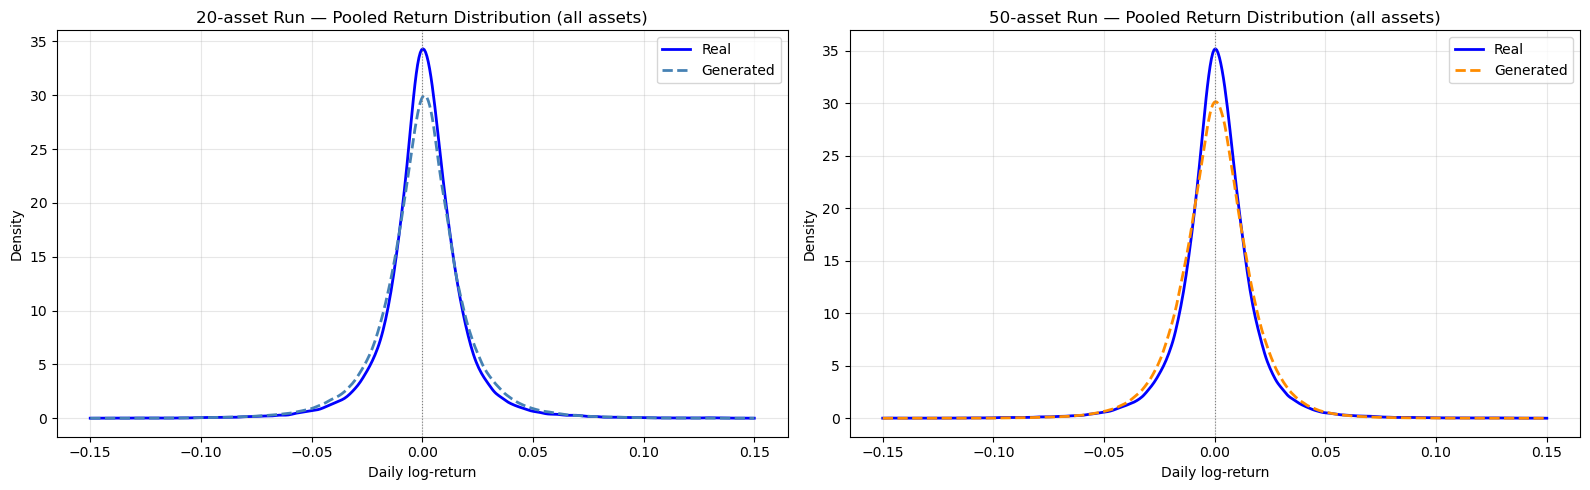

In [20]:
# Pool all returns across all assets for each dataset
flat_real_20 = real_20.values.flatten()
flat_real_50 = real_50.values.flatten()
flat_gen_20  = gen_20.values.flatten()
flat_gen_50  = gen_50.values.flatten()

# Remove NaNs from real data
flat_real_20 = flat_real_20[~np.isnan(flat_real_20)]
flat_real_50 = flat_real_50[~np.isnan(flat_real_50)]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

clip = (-0.15, 0.15)  # clip for readability

for ax, (flat_real, flat_gen, label, color) in zip(axes, [
    (flat_real_20, flat_gen_20, "20-asset Run",  "steelblue"),
    (flat_real_50, flat_gen_50, "50-asset Run", "darkorange"),
]):
    r_clip = flat_real[(flat_real >= clip[0]) & (flat_real <= clip[1])]
    g_clip = flat_gen[(flat_gen   >= clip[0]) & (flat_gen  <= clip[1])]

    kde_real = stats.gaussian_kde(r_clip)
    kde_gen  = stats.gaussian_kde(g_clip)
    x = np.linspace(clip[0], clip[1], 500)

    ax.plot(x, kde_real(x), "b-",  linewidth=2, label="Real")
    ax.plot(x, kde_gen(x),  linestyle="--", linewidth=2, color=color, label="Generated")
    ax.axvline(0, color="gray", linewidth=0.8, linestyle=":")
    ax.set_xlabel("Daily log-return")
    ax.set_ylabel("Density")
    ax.set_title(f"{label} — Pooled Return Distribution (all assets)")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(ARTIFACT_ROOT / "dist_pooled_kde.png", dpi=150)
plt.show()

## 2. Q-Q Plot vs Normal Distribution

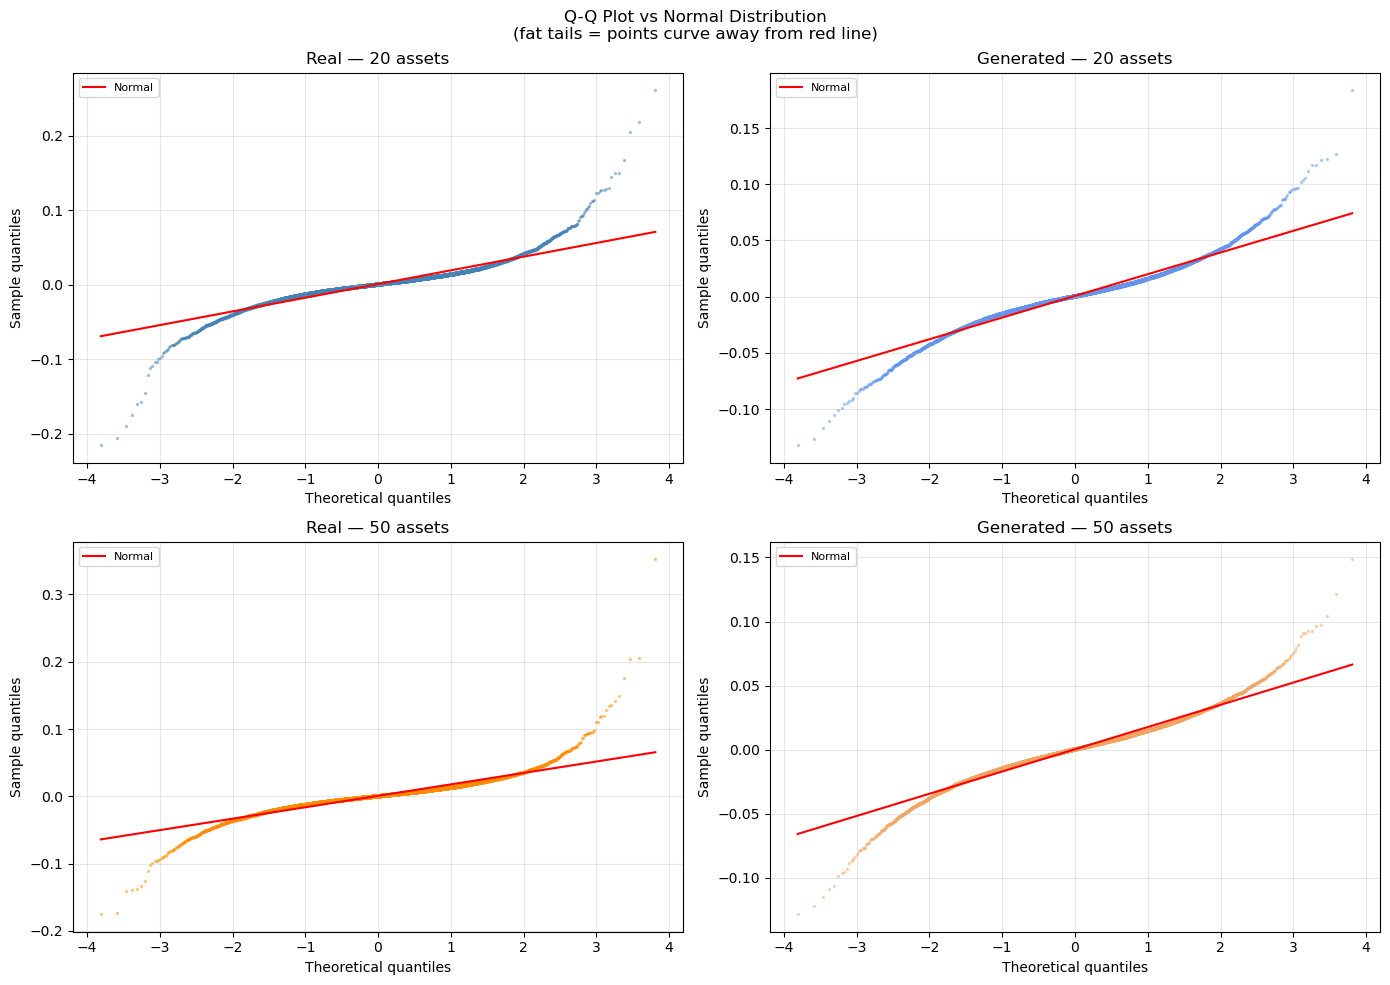

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

datasets = [
    (flat_real_20, "Real — 20 assets",      "steelblue"),
    (flat_gen_20,  "Generated — 20 assets", "cornflowerblue"),
    (flat_real_50, "Real — 50 assets",      "darkorange"),
    (flat_gen_50,  "Generated — 50 assets", "sandybrown"),
]

for ax, (data, label, color) in zip(axes.flat, datasets):
    # Subsample for speed
    sample = np.random.choice(data, size=min(10000, len(data)), replace=False)
    (osm, osr), (slope, intercept, _) = stats.probplot(sample, dist="norm")
    ax.scatter(osm, osr, s=2, alpha=0.4, color=color)
    ax.plot(osm, slope * np.array(osm) + intercept, "r-", linewidth=1.5, label="Normal")
    ax.set_xlabel("Theoretical quantiles")
    ax.set_ylabel("Sample quantiles")
    ax.set_title(label)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle("Q-Q Plot vs Normal Distribution\n(fat tails = points curve away from red line)", fontsize=12)
plt.tight_layout()
plt.savefig(ARTIFACT_ROOT / "dist_qq_normal.png", dpi=150)
plt.show()

## 3. Per-Asset KDE — Selected Stocks (common to both runs)

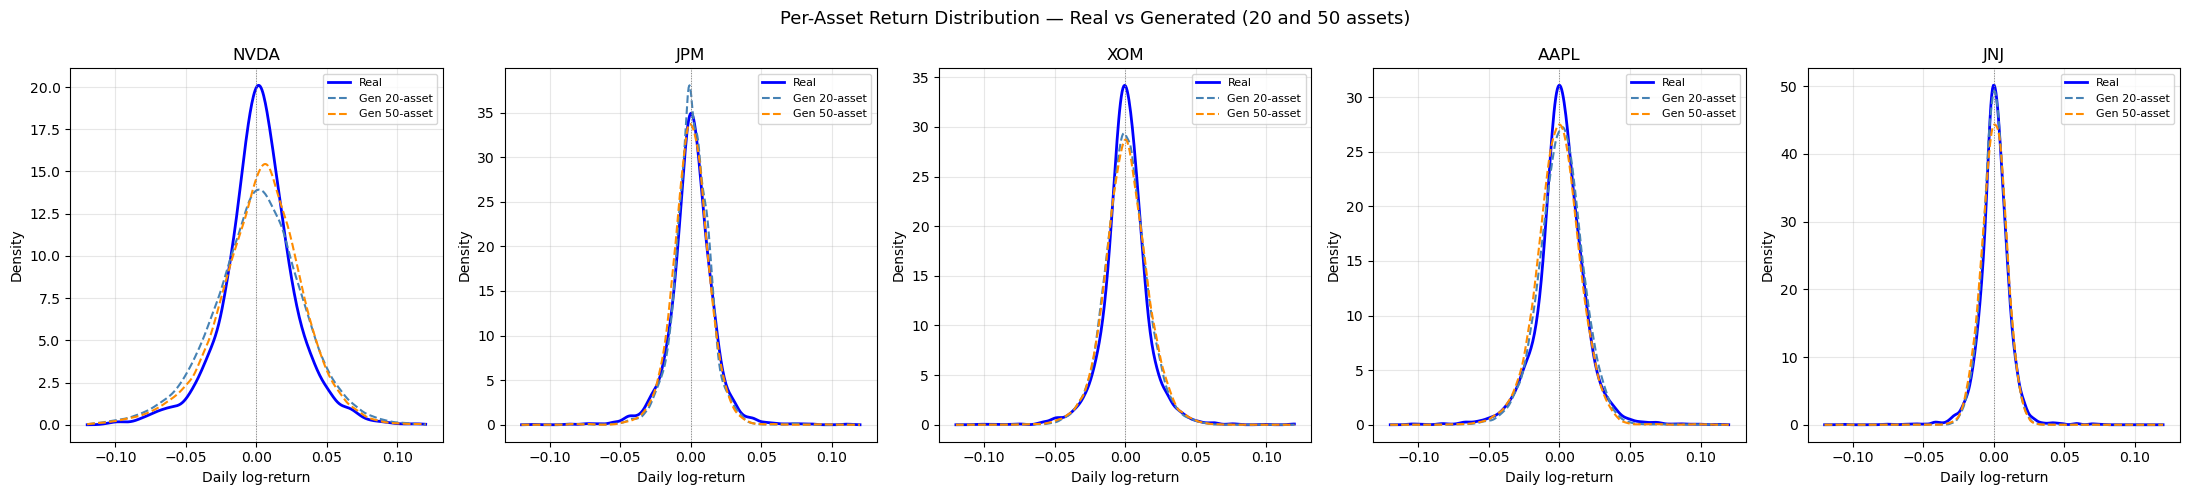

In [22]:
# Pick 5 representative stocks: high-vol tech, financials, energy, consumer, healthcare
SELECTED = [a for a in ["nvda", "jpm", "xom", "aapl", "jnj"] if a in common_assets]

fig, axes = plt.subplots(1, 5, figsize=(22, 5))

for ax, asset in zip(axes, SELECTED):
    real_vals = real_all[asset].dropna().values
    gen_20_vals = gen_20[asset].values if asset in gen_20.columns else None
    gen_50_vals = gen_50[asset].values if asset in gen_50.columns else None

    x = np.linspace(-0.12, 0.12, 400)

    kde_r = stats.gaussian_kde(real_vals[(real_vals >= -0.12) & (real_vals <= 0.12)])
    ax.plot(x, kde_r(x), "b-", linewidth=2, label="Real")

    if gen_20_vals is not None:
        g20 = gen_20_vals[(gen_20_vals >= -0.12) & (gen_20_vals <= 0.12)]
        if len(g20) > 10:
            ax.plot(x, stats.gaussian_kde(g20)(x), "--", color="steelblue", linewidth=1.5, label="Gen 20-asset")

    if gen_50_vals is not None:
        g50 = gen_50_vals[(gen_50_vals >= -0.12) & (gen_50_vals <= 0.12)]
        if len(g50) > 10:
            ax.plot(x, stats.gaussian_kde(g50)(x), "--", color="darkorange", linewidth=1.5, label="Gen 50-asset")

    ax.axvline(0, color="gray", linewidth=0.7, linestyle=":")
    ax.set_title(asset.upper())
    ax.set_xlabel("Daily log-return")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle("Per-Asset Return Distribution — Real vs Generated (20 and 50 assets)", fontsize=13)
plt.tight_layout()
plt.savefig(ARTIFACT_ROOT / "dist_per_asset_kde.png", dpi=150)
plt.show()

## 4. Summary Statistics Table

In [23]:
def summary_stats(arr):
    arr = arr[~np.isnan(arr)]
    return {
        "mean":     arr.mean(),
        "std":      arr.std(),
        "skew":     stats.skew(arr),
        "kurtosis": stats.kurtosis(arr),   # excess kurtosis
        "5th pct":  np.percentile(arr, 5),
        "1st pct":  np.percentile(arr, 1),
    }

rows = {
    "Real (20-asset universe)": summary_stats(flat_real_20),
    "Generated — 20-asset run (VAL)": summary_stats(flat_gen_20),
    "Real (50-asset universe)": summary_stats(flat_real_50),
    "Generated — 50-asset run (TEST)": summary_stats(flat_gen_50),
}

summary_df = pd.DataFrame(rows).T
print(summary_df.round(6).to_string())

                                     mean       std      skew   kurtosis   5th pct   1st pct
Real (20-asset universe)         0.000787  0.019681 -0.212036  21.041345 -0.027399 -0.054826
Generated — 20-asset run (VAL)   0.000604  0.020156  0.112911   6.450295 -0.031137 -0.056618
Real (50-asset universe)         0.000642  0.018401 -0.212058  18.971083 -0.025961 -0.051152
Generated — 50-asset run (TEST)  0.000400  0.017856  0.045710   5.427883 -0.027896 -0.048399
